In [30]:
# load in pandas df in ../..//Week10/PurpleData.pkl 
import pandas as pd

df = pd.read_pickle('../../Week10/PurpleData.pkl')
df.head()

,R,G,B,Class
0,221.0,62.0,205.0,1
1,157.0,47.0,181.0,1
2,128.0,0.0,255.0,1
3,148.0,0.0,211.0,1
4,145.0,55.0,213.0,1


In [31]:
print(df[['R', 'G', 'B']].describe())

                R           G           B
count  106.000000  106.000000  105.000000
mean   131.292453   84.396226  160.457143
std     71.832473   78.668403   82.017239
min      0.000000    0.000000    0.000000
25%     77.750000   18.000000  119.000000
50%    128.000000   57.500000  180.000000
75%    189.000000  129.500000  225.000000
max    255.000000  255.000000  255.000000


In [32]:
print(df['Class'].unique())

[1, 0]
Categories (2, int64): [0, 1]


In [33]:
df

,R,G,B,Class
0,221.0,62.0,205.0,1
1,157.0,47.0,181.0,1
2,128.0,0.0,255.0,1
3,148.0,0.0,211.0,1
4,145.0,55.0,213.0,1
5,189.0,77.0,185.0,1
6,169.0,26.0,230.0,1
7,141.0,28.0,255.0,1
8,153.0,51.0,255.0,1
9,55.0,11.0,107.0,1


In [34]:
df.dropna(inplace=True)
df['Class'].value_counts()

1    57
0    48
Name: Class, dtype: int64

In [35]:
# show all rows in pandas 
pd.set_option('display.max_rows', None)

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 105 entries, 0 to 105
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   R       105 non-null    float64 
 1   G       105 non-null    float64 
 2   B       105 non-null    float64 
 3   Class   105 non-null    category
dtypes: category(1), float64(3)
memory usage: 3.5 KB


In [36]:
print(df[['R', 'G', 'B']].describe())

                R           G           B
count  105.000000  105.000000  105.000000
mean   132.257143   83.219048  160.457143
std     71.483730   78.102002   82.017239
min      0.000000    0.000000    0.000000
25%     80.000000   17.000000  119.000000
50%    128.000000   57.000000  180.000000
75%    189.000000  128.000000  225.000000
max    255.000000  255.000000  255.000000


# Build a fully connected Pytorch NN to Classify Class from R, G and B in df

In [40]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F

# Define the neural network
class SimpleNN(nn.Module):
    def __init__(self, input_size=3, hidden_size=3, dropout_prob=0.5):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(p=dropout_prob)
        self.fc2 = nn.Linear(hidden_size, 1)  # Single output for binary classification
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # No sigmoid here; handled by BCEWithLogitsLoss
        return x

# Preprocess the data
# Normalize the input features to the range [0, 1]
X = df[['R', 'G', 'B']].values / 255.0  # Assuming RGB values are in the range [0, 255]
y = df['Class'].values          # Target column (binary: 0/1)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # Add dimension for binary classification

# Create a DataLoader for batching
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)  # Batch size of 16

# Instantiate the model
input_size = 3  # Number of input features (R, G, B)
hidden_size = 3  # Number of neurons in the hidden layer
dropout_prob = 0.5  # Dropout probability
model = SimpleNN(input_size, hidden_size, dropout_prob)

print(model)

def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

model.apply(initialize_weights)

# Define the loss function and optimizer
criterion = nn.BCEWithLogitsLoss()  # Combines sigmoid and binary cross-entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 20  # Number of epochs
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    for batch_X, batch_y in dataloader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Print loss for each epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Save the trained model
torch.save(model.state_dict(), 'simple_nn_model.pth')
print("Model training complete and saved.")

# Evaluate the model
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    outputs = model(X_tensor)
    predictions = torch.sigmoid(outputs).round()  # Apply sigmoid and round to get binary predictions
    accuracy = (predictions.eq(y_tensor).sum().item()) / y_tensor.size(0)
    print(f"Model Accuracy: {accuracy:.4f}")

SimpleNN(
  (fc1): Linear(in_features=3, out_features=3, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=3, out_features=1, bias=True)
)
Epoch [1/20], Loss: 0.7114
Epoch [2/20], Loss: 0.6609
Epoch [3/20], Loss: 0.6972
Epoch [4/20], Loss: 0.6864
Epoch [5/20], Loss: 0.6873
Epoch [6/20], Loss: 0.7176
Epoch [7/20], Loss: 0.7006
Epoch [8/20], Loss: 0.6915
Epoch [9/20], Loss: 0.6548
Epoch [10/20], Loss: 0.7244
Epoch [11/20], Loss: 0.6552
Epoch [12/20], Loss: 0.6615
Epoch [13/20], Loss: 0.6359
Epoch [14/20], Loss: 0.6754
Epoch [15/20], Loss: 0.6989
Epoch [16/20], Loss: 0.6262
Epoch [17/20], Loss: 0.6466
Epoch [18/20], Loss: 0.6768
Epoch [19/20], Loss: 0.7136
Epoch [20/20], Loss: 0.6908
Model training complete and saved.
Model Accuracy: 0.7238


# Visualize the model

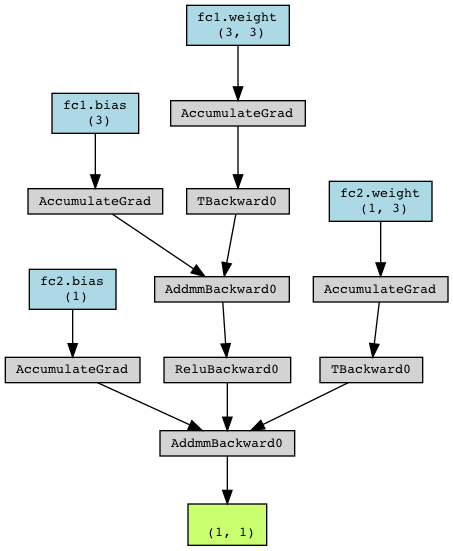

In [42]:
from torchviz import make_dot

# Create a dummy input tensor with the same shape as your input data
dummy_input = torch.randn(1, 3)  # Batch size of 1, 3 input features (R, G, B)

# Pass the dummy input through the model to generate the computational graph
output = model(dummy_input)

# Visualize the model
dot = make_dot(output, params=dict(model.named_parameters()))
dot.format = 'png'  # Save as a PNG file
dot.render('model_visualization')  # This will save the file as 'model_visualization.png'

# Display the visualization in Jupyter Notebook (if applicable)
from IPython.display import Image
Image(filename='model_visualization.png')

In [47]:
# import plotly.graph_objects as go
import numpy as np

def draw_neural_network_plotly(model):
    """
    Draws a neural network diagram with weights and biases using Plotly.
    
    Args:
        model: PyTorch model (SimpleNN) to extract weights and biases.
    """
    # Extract weights and biases from the model
    weights_1 = model.fc1.weight.detach().numpy()
    biases_1 = model.fc1.bias.detach().numpy()
    weights_2 = model.fc2.weight.detach().numpy()
    biases_2 = model.fc2.bias.detach().numpy()
    
    # Define layer sizes
    input_size = weights_1.shape[1]
    hidden_size = weights_1.shape[0]
    output_size = weights_2.shape[0]
    layer_sizes = [input_size, hidden_size, output_size]
    
    # Define horizontal and vertical spacing
    h_spacing = 1.0 / (len(layer_sizes) - 1)
    v_spacing = 1.0 / max(layer_sizes)
    
    # Store node positions
    positions = {}
    for i, layer_size in enumerate(layer_sizes):
        for j in range(layer_size):
            x = i * h_spacing
            y = 1 - j * v_spacing * (max(layer_sizes) / layer_size)  # Center nodes vertically
            positions[(i, j)] = (x, y)
    
    # Create Plotly figure
    fig = go.Figure()
    
    # Add nodes with biases
    for (i, j), (x, y) in positions.items():
        bias = None
        if i == 1:  # Hidden layer
            bias = biases_1[j]
        elif i == 2:  # Output layer
            bias = biases_2[j]
        
        fig.add_trace(go.Scatter(
            x=[x], y=[y],
            mode='markers+text',
            marker=dict(size=30, color='lightblue', line=dict(width=2, color='black')),
            text=f"b={bias:.2f}" if bias is not None else "",
            textposition="top center",
            showlegend=False
        ))
    
    # Add edges with weights
    for i, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        for j in range(layer_size_a):
            for k in range(layer_size_b):
                x1, y1 = positions[(i, j)]
                x2, y2 = positions[(i + 1, k)]
                weight = weights_1[k, j] if i == 0 else weights_2[0, k]
                fig.add_trace(go.Scatter(
                    x=[x1, x2], y=[y1, y2],
                    mode='lines+text',
                    line=dict(color='gray', width=1),
                    text=[None, f"w={weight:.2f}"],
                    textposition="middle center",
                    textfont=dict(size=8),
                    showlegend=False
                ))
    
    # Update layout
    fig.update_layout(
        title="Neural Network Diagram",
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='white',
        width=800,
        height=600
    )
    
    # Show the figure
    fig.show()

# Call the function to draw the neural network
draw_neural_network_plotly(model)